Importing libraries and setting up simulator

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import configparser
from scipy import stats
from sklearn.metrics import roc_curve, auc

In [3]:
#pmt details
!curl -O https://raw.githubusercontent.com/XENON1T/pax/refs/heads/master/pax/config/XENON1T.ini
config = configparser.ConfigParser()
config.read('XENON1T.ini')
pmt_config = eval(config['DEFAULT']['pmts'])
pmt_positions = np.array([(x['position']['x'], x['position']['y'])
                           for x in pmt_config if x.get('array', '') == 'top'])
tpc_radius = 47.9

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
100 303.3k 100 303.3k   0      0 954.6k      0                              0
100 303.3k 100 303.3k   0      0 954.1k      0                              0
100 303.3k 100 303.3k   0      0 953.8k      0                              0


Simulator

In [4]:
def mean_response(xy):
    """Return normalized mean response of PMTs to light emission at xy"""
    a = -2.7e-5
    b = 3.6e-3
    i0 = 0.290
    d = 12.13
    p = 2.35
    # Compute distance from xy to pmt position
    # xy has shape (positions, 2)
    # pmt_positions has shape (pmts, 2)
    # Output should have shape (positions, pmts)
    rho = np.linalg.norm(xy[:, None, :] - pmt_positions[None, :, :], axis=2)
    raw_lce = i0 * (1-b) / (1 + (rho/d)**2)**p + a * rho + b
    # Normalize to 1
    return raw_lce / np.sum(raw_lce, axis=1)[:, None]

def simulate_signal(xy, photons=10_000):
    """Simulate a signal where an average number of photons are detected by PMTs at xy"""
    lce = mean_response(xy)
    # Random photon detection
    photons_detected = np.random.poisson(photons * lce)
    # Double photoelectron emission
    pe_detected = photons_detected + np.random.binomial(photons_detected, 0.2)
    # Gaussian smearing
    return np.random.normal(pe_detected, 0.3 * np.sqrt(pe_detected))


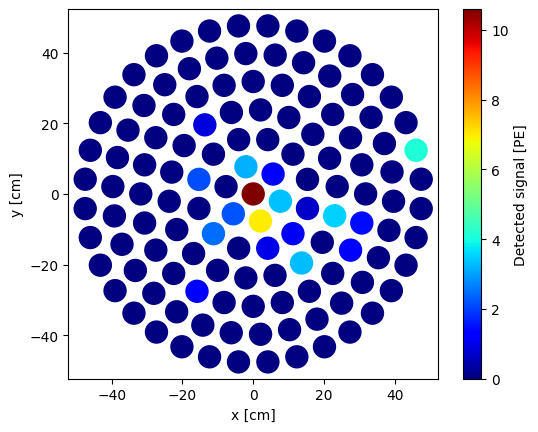

In [5]:
#if the user is so inclined, this code can be used to plot a signal sample of the array
def plot_signal(signal):
    """Plot the signal detected by the PMTs"""
    plt.scatter(*pmt_positions.T, c=signal, cmap='jet', s=250, vmin=0)
    plt.colorbar(label='Detected signal [PE]')
    plt.gca().set_aspect('equal')
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')

plot_signal(simulate_signal(np.array([[0, 0]]), photons=30).sum(axis=0))

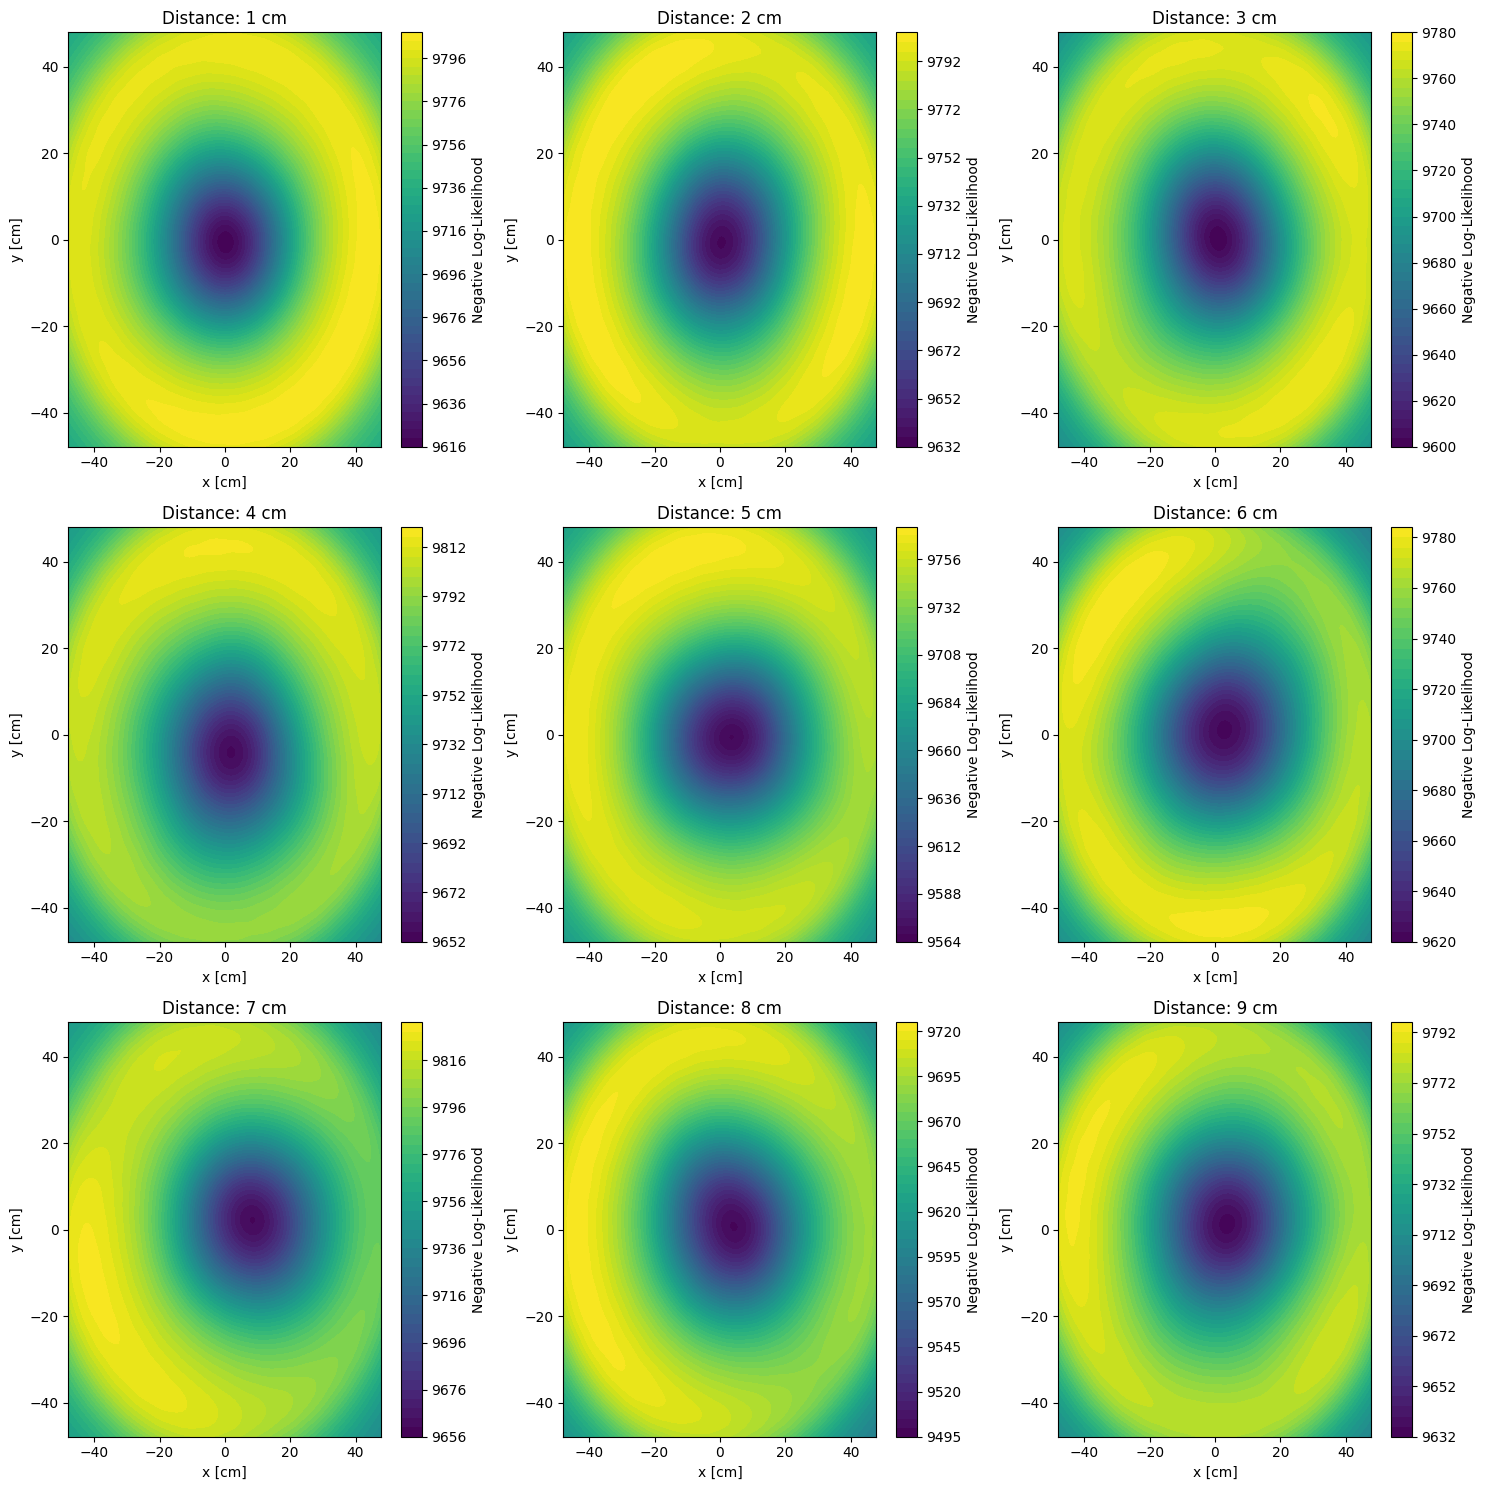

In [ ]:
# Plotting loss landscape
def loss_function(xy, signal):
    """Negative log-likelihood of observing signal given mean response at xy. The log likelihood is defined as the sum of the log of the Poisson probabilities for each PMT, given the expected signal from the mean response at xy."""
    lce = mean_response(xy)
    expected_signal = 10_000 * lce  # Assuming 10k photons emitted
    # Poisson likelihood
    return -np.sum(signal * np.log(expected_signal + 1e-6) - expected_signal)

def plot_loss_landscape(signal):
    """Plot the loss landscape over the TPC area."""
    x = np.linspace(-tpc_radius, tpc_radius, 200)
    y = np.linspace(-tpc_radius, tpc_radius, 200)
    X, Y = np.meshgrid(x, y)
    Z = np.array([[loss_function(np.array([[x, y]]), signal) for x in x] for y in y])
    plt.contourf(X, Y, Z, levels=50)
    plt.colorbar(label='Negative Log-Likelihood', cmap='Greys')
    plt.xlabel('x [cm]')
    plt.ylabel('y [cm]')
    plt.title('Loss Landscape')

#make array of plots of loss landscapes for double scatter signals for different distances 5, 10, 20, 30, 40, 50, 60, 70, 80
distances = [1,2,3,4,5,6,7,8,9]
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, d in zip(axes.flatten(), distances):
    # Simulate double scatter signal
    signal1 = simulate_signal(np.array([[0, 0]]), photons=30)
    signal2 = simulate_signal(np.array([[d, 0]]), photons=30)
    combined_signal = signal1 + signal2
    # Plot loss landscape
    plt.sca(ax)
    plot_loss_landscape(combined_signal)
    ax.set_title(f'Distance: {d} cm')
plt.tight_layout()
plt.show()

Hitpatroon erbij plotten

In [37]:
#grid search for best fit position
x = np.linspace(-tpc_radius, tpc_radius, 200)
y = np.linspace(-tpc_radius, tpc_radius, 200)
X, Y = np.meshgrid(x, y)
def grid_search(signal):
    """Perform a grid search to find the best fit position for the observed signal"""
    Z = np.array([[loss_function(np.array([[x, y]]), signal) for x in x] for y in y])
    min_idx = np.unravel_index(np.argmin(Z), Z.shape)
    return X[min_idx], Y[min_idx], Z[min_idx]

#execute grid search for a double scatter signal at 20 cm distance
signal1 = simulate_signal(np.array([[0, 0]]), photons=30)
signal2 = simulate_signal(np.array([[20, 0]]), photons=30)
combined_signal = signal1 + signal2
best_x, best_y, best_loss = grid_search(combined_signal)
print(f'Best fit position: ({best_x:.2f}, {best_y:.2f}), Loss: {best_loss:.2f}')

#local optimizer with grid search output as initial guess
from scipy.optimize import minimize
def local_optimization(signal, initial_guess):
    """Perform local optimization starting from the initial guess"""
    result = minimize(lambda xy: loss_function(xy.reshape(1, -1), signal), 
                      x0=initial_guess, 
                      bounds=[(-tpc_radius, tpc_radius), (-tpc_radius, tpc_radius)])
    return result.x[0], result.x[1], result.fun

#execute local optimization for the same double scatter signal
initial_guess = (best_x, best_y)
opt_x, opt_y, opt_loss = local_optimization(combined_signal, initial_guess)
print(f'Optimized position: ({opt_x:.2f}, {opt_y:.2f}), Loss: {opt_loss:.2f}')



Best fit position: (7.94, 1.68), Loss: 9635.11
Optimized position: (7.96, 1.55), Loss: 9635.10
